# Evaluating ML Classifier Performance & Model Interpretability:

### Introduction:

This Jupyter notebook evaluates the interpretability of the biotic-abiotic classification framework incorporated into the Python package [`mlbiosig`](../../mlbiosig/) and developed across the four previous notebooks. Four classifiers (Logistic Regression, SVC, Random Forest, and XGBoost) trained to distinguish pyrolysis-Gas Chromatography-Mass Spectrometry (py-GC-MS) samples as biotic or abiotic based on their extracted mass spectra are evaluated using the entire dataset of $140$ biotic and $14$ abiotic samples. A detailed breakdown of the full sample set is provided in the following [documentation](../../docs/total-sample-breakdown.md). 

Evaluation spans both classifier performance and model interpretability through:
* Performing principal component analysis (PCA) on the full sample set to investigate the dominant $m/z$ features of geochemical variation behind each PC. 
* Comparing classifier performance using:
    * Confusion matrices.
    * Receiver Operating Characteristic (ROC) curves.
* Interpreting model predictions through:
    * Permutation feature importance.
    * Coefficient analysis.
    * SHapley Additive exPlanations (SHAP) to quantify the contributions of individual $m/z$ features that drive classification.

This will be the final framework to be developed and integrated into `mlbiosig`, in order to bridge model evaluation with interpretation.

### Imports:

In [1]:
# mlbiosig package imports:
from mlbiosig import (
    samples_labels,
    classify_samples,
    plot_loadings,
    build_features,
    engineer_features,
    train_evaluate_classifiers,
)

# ML evaluation/visualisation imports:
from sklearn.inspection import permutation_importance
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay, confusion_matrix
from sklearn.decomposition import PCA

# ML interpretability imports:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr
from collections import defaultdict
from sklearn.base import clone
import shap

# Misc. Imports
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
import numpy as np
import pandas as pd

### Generating & Engineering py-MS Features:

As this notebook serves as the final stage of developing the `mlbiosig` Python tool, all performance evaluations and visualisation metrics will be applied on the entire sample set of $140$ biotics and $14$ abiotics.

In [2]:
# Obtain biotic & abiotic py-GC-MS mass spectra CSV filepaths:
filepaths, labels = samples_labels()  # filepaths and label ('biotic'/'abiotic')
print(
    f"Total Samples: {len(filepaths)} | Total Biotic: {labels.count('biotic')} | Total Abiotic: {labels.count('abiotic')}"
)

Total Samples: 154 | Total Biotic: 140 | Total Abiotic: 14


In [3]:
# Build features:
feature_matrix, flags = build_features(filepaths, labels)

Preprocessing py-GC-MS samples:   0%|          | 0/154 [00:00<?, ?sample/s]

In [4]:
# Engineer features:
X_train, X_test, y_train, y_test, le, selector = engineer_features(feature_matrix)

In [5]:
print(
    f"Training Set Samples: {X_train.shape[0]} | Testing Set Samples: {X_test.shape[0]}"
)
print(f"No. of m/z Features: {X_train.shape[1]}")

Training Set Samples: 123 | Testing Set Samples: 31
No. of m/z Features: 235


### Complete Biotic-Abiotic Dataset PCA:

**Performing PCA & Determining Sample Subtype Clusters**

A [previous notebook](02_feature_engineering.ipynb) only performed PCA on a more balanced subset set of $32$ biotics and $14$ abiotics. Here, PCA will be repeated using the entire sample set to visualise how well the feature engineering module in `mlbiosig` captures the underlying sample-type chemical relationships beyond biotic-abiotic discrimination. Based on the previous scree and explained variance analyses to determine the optimal number of PCs $k$, $k = 2$ will be retained. 

In [6]:
# Initialise principal components (PCs):
k = 2
pca = PCA(n_components=k)

# Reduce training data into k = 2:
X_train_pca = pca.fit_transform(X_train)
explained_var = pca.explained_variance_ratio_

In [7]:
# Definining sample-type categories based on CSV filename:
cats = {
    "SHEW": "Shewanella",
    ("_CH", "CHLOR"): "Chlorella",
    "SP": "Spirulina",
    ("WC", "WL", "KEROGEN", "CBN", "CD3", "LF1", "RMP1", "GRS"): "Kerogen",
    ("BARLEY", "CHESTNUT", "CW", "PINE", "PB", "RICE", "EUCALYPTUS"): "Biochar",
    "CELLULOSE": "Cellulose",
    "LIGNIN": "Lignin",
    ("PP", "PS", "PVC"): "Plastics",
    ("AMBER", "FRANK", "DAMMAR", "MYRRH", "ROSIN"): "Resin",
    ("WAX", "CARNAUBA", "MICRO"): "Wax",
    ("LOWVOL", "HIGHVOL", "DM_"): "Coal",
    ("MURCHISON", "WINC", "ALLENDE", "NWA"): "Meteorite",
    ("CACO3", "GOET", "MAG", "KAOL", "NONT", "SERP"): "Mineral",
    "MEMBRANE": "Membrane Lipid",
}

In order to visualise the sample-type clustering of points in PC1-PC2 space, covariance ellipses are annotated on the PCA plot below. Using a helper function `confidence_ellipse`(Matplotlib Development Team 2026), confidence ellipses are plotted. The radii of the ellipses are determined by the number of standard deviations, $\sigma$, from the mean captured by the covariance of PC1-PC2. $\sigma = 3$ is chosen, where each ellipse will contain $\sim 99\%$ coverage of the data points for each sample-type, allowing better visibility of the main cluster structure. Not all sample-type covariance ellipses are plotted for clarity, so that the underlying data points can still remain visible.

In [8]:
def confidence_ellipse(x, y, ax, n_std=3.0, **kwargs):
    """
    Create a plot of the covariance confidence ellipse of x and y. This function,
    in its entirety, was taken from (Matplotlib Development Team 2026).

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.
    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.
    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.
    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1] / np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)

    ellipse = Ellipse(
        (0, 0),
        width=ell_radius_x * 2,
        height=ell_radius_y * 2,
        facecolor="none",
        **kwargs,
    )

    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = (
        transforms.Affine2D()
        .rotate_deg(45)
        .scale(scale_x, scale_y)
        .translate(mean_x, mean_y)
    )

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

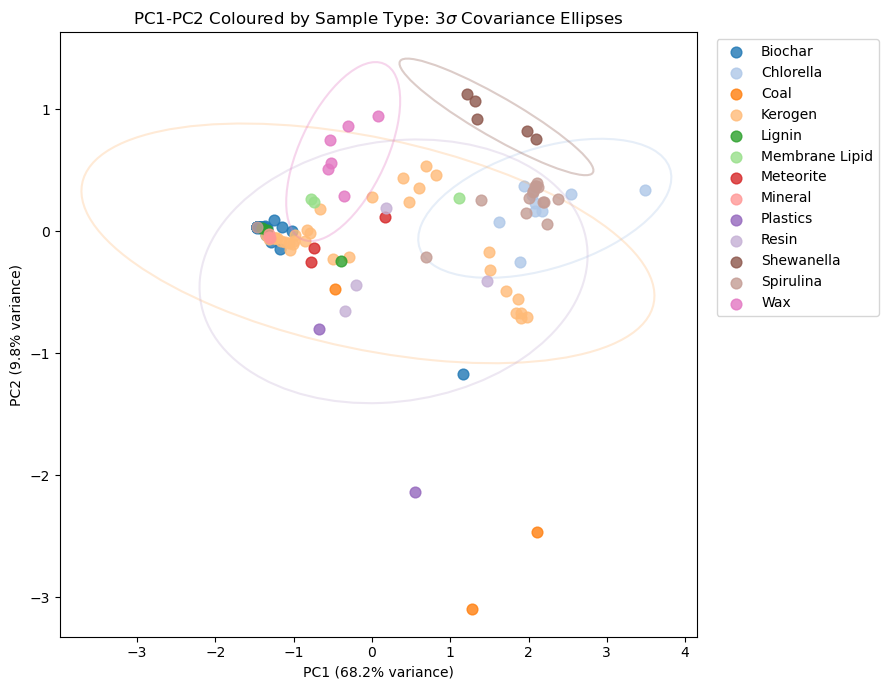

In [22]:
# Plotting PC1 and PC2 and colour-coding different sample categories
plt.figure(figsize=(9, 7))
sample_type = [classify_samples(name, cats) for name in X_train.index]
colors = plt.get_cmap("tab20").colors  # unique colors
circle_groups = ["Shewanella", "Chlorella", "Plastics", "Wax", "Resin", "Kerogen"]

for colour, group in zip(colors, np.unique(sample_type)):
    mask = np.array(sample_type) == group
    plt.scatter(
        X_train_pca[mask, 0],
        X_train_pca[mask, 1],
        color=colour,
        label=group,
        s=60,
        alpha=0.8,
    )

    # add covariance circles to PCA for sample type clusters > 3 points:
    if group in circle_groups and len(X_train_pca[mask, 0]) >= 3:
        confidence_ellipse(
            X_train_pca[mask, 0],
            X_train_pca[mask, 1],
            plt.gca(),
            n_std=3,
            edgecolor=colour,
            alpha=0.3,
            linewidth=1.5,
            linestyle="-",
        )

plt.xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
plt.title(rf"PC1-PC2 Coloured by Sample Type: 3$\sigma$ Covariance Ellipses")
# move legend out of plot:
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

**Interpreting PC1-PC2 Space & Loadings**

The sample-type clusters shown within PC1-PC2 space closely resembles, and strengthens, the trends seen in the [previous notebook](02_feature_engineering.ipynb). Biochar, meteorites, resins and waxes occupy the negative side of PC1, while kerogens span both the negative and positive regions of PC1. *Shewanella*, *Spirulina*, and *Chlorella* cluster on the positive side of PC1, while coal aligns with these samples along PC1 but remains completely separated along the negative PC2 axis. 

This wide separation across the chemically diverse set of biotic and abiotic samples demonstrates that the engineered features effectively capture meaningful geochemical variation prior to supervised classification. PC1, accounting for $\sim 68 \%$ of the total variance, appears to represent the primary source of chemical variation that seems consistent with differences in composition and geochemical maturity:
* Negative PC1: inert carbon and inorganic matter i.e., biochar and meteorites.
* Positive PC1: hydrogen-rich organic matter i.e., microbes and coal.
This clustering could therefore suggest that variation in hydrocarbon abundances drive separation along PC1. 

The distribution of coal along PC1 further supports this interpretation, as coal samples cluster in different positions according to their maturity (otherwise known as 'rank') with highly volatile coal most likely aligning closer with microbial samples on the positive side of PC1. This behaviour will be investigated further by distinguishing coal (demineralised, high volatile, low volatile) and biochar (Barley Straw, Chestnut Wood, Pine Bark, Rice Husk, Eucalyptus Bark) subtypes within the PCA plots below.

In [28]:
# Defining biochar & coal sub-sample types:
maturity_cats = {
    "BARLEY": "Barley Straw",
    ("CHESTNUT", "CW"): "Chestnut Wood",
    ("PINE", "PB"): "Pine Bark",
    "RICE": "Rice Husk",
    "EUCALYPTUS": "Eucalyptus Bark",
    "LOWVOL": "Low Volatile Coal",
    "HIGHVOL": "High Volatile Coal",
    "DM_": "Demineralised Coal",
}

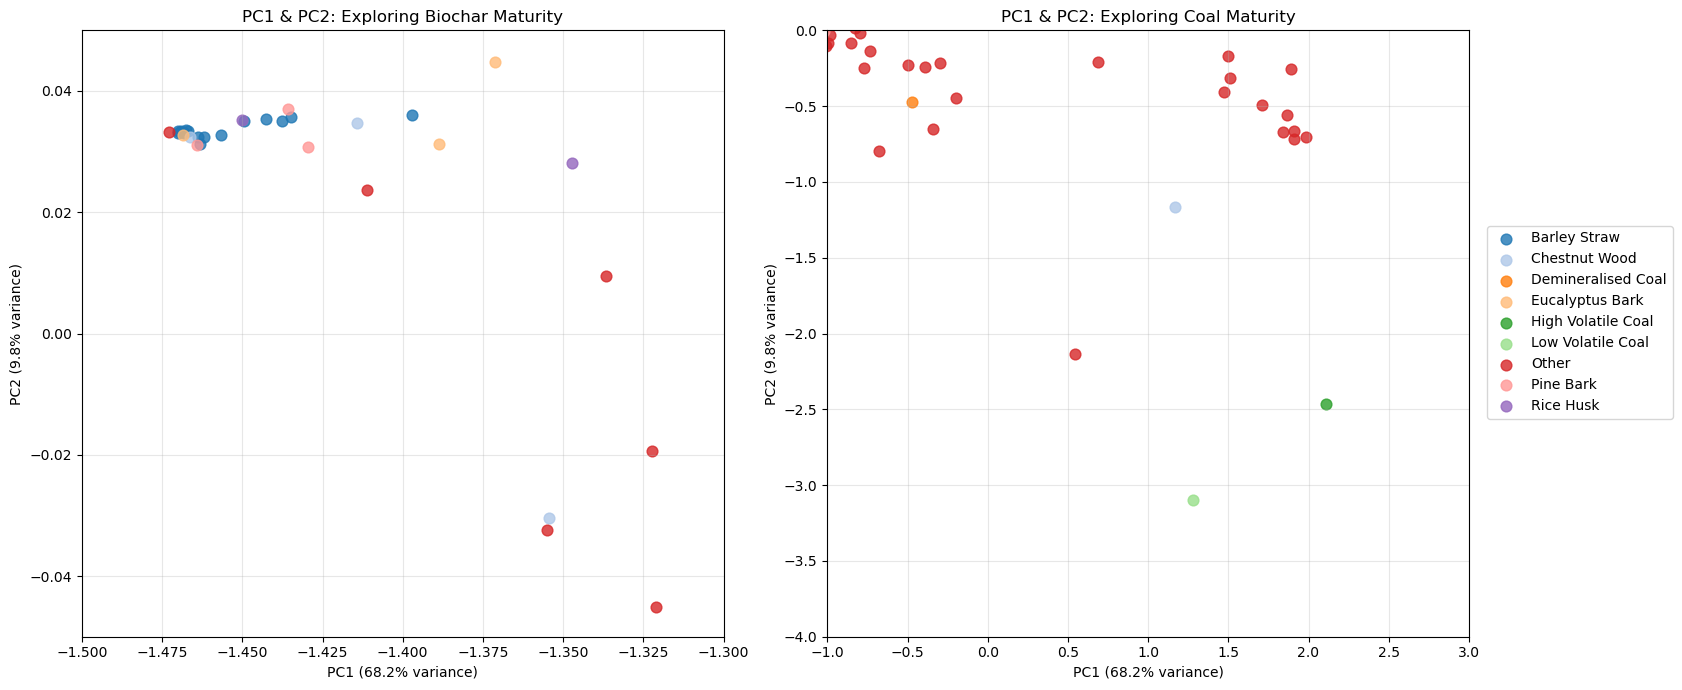

In [30]:
# Plotting PC1 and PC2 and colour-coding different biochar & coal samples:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

sample_type = [classify_samples(name, maturity_cats) for name in X_train.index]
colors = plt.get_cmap("tab20").colors

for ax in axes:
    for colour, group in zip(colors, np.unique(sample_type)):
        mask = np.array(sample_type) == group

        ax.scatter(
            X_train_pca[mask, 0],
            X_train_pca[mask, 1],
            color=colour,
            label=group,
            s=60,
            alpha=0.8,
        )

    ax.set_xlabel(f"PC1 ({explained_var[0]*100:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({explained_var[1]*100:.1f}% variance)")
    ax.grid(True, alpha=0.3)

# Full view
axes[0].set_title("PC1 & PC2: Exploring Biochar Maturity")
axes[0].set_xlim(-1.5, -1.3)
axes[0].set_ylim(-0.05, 0.05)

# Zoomed view
axes[1].set_title("PC1 & PC2: Exploring Coal Maturity")
axes[1].set_xlim(-1, 3)
axes[1].set_ylim(-4, 0)

# One legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(0.99, 0.68), loc="upper left")

plt.tight_layout()
plt.show()

The above subtype analysis on the coal rank and biochar's geochemical variation reinforces my interpretation. In the left panel, biochar forms a tight cluster on the negative PC1 axis while biochar sub-types such as Barley Straw and Eucalyptus Bark remain separate and distinguishable. In the right panel, highly volatile coal sits on the positive PC1 axis closer to microbial samples, in line with previous studies demonstrating liptinite content in high volatile coal derived from plant and algal matter (Radke 1980).

Interpretation of the corresponding loading vectors (otherwise referred to as 'loadings') can provide further insight into the specific $m/z$ features driving separation in PC1.

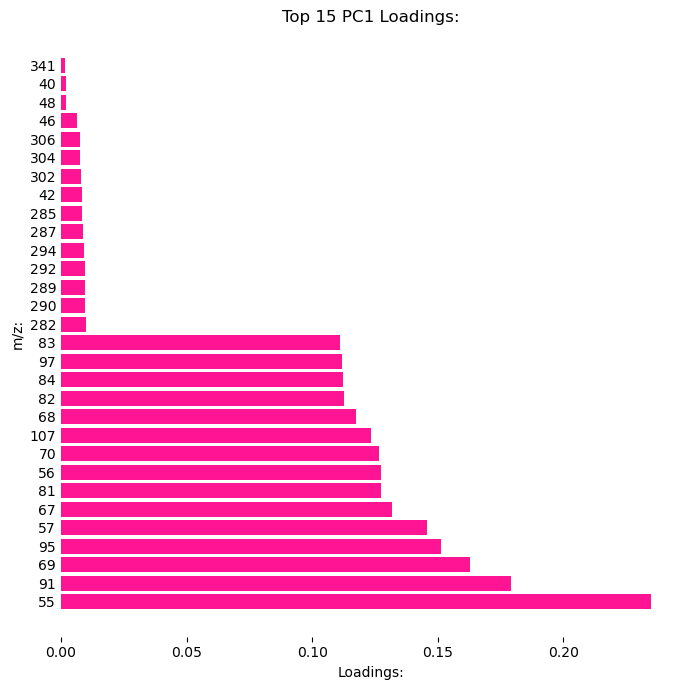

In [11]:
# Loadings to find contribution of each m/z feature to PC1 & PC2:
loadings = (pca.components_.T) * (np.sqrt(explained_var))
loadings_df = pd.DataFrame(
    loadings,  # rows = m/z, columns = PCs
    index=X_train.columns,  # m/z values
    columns=["PC1", "PC2"],
)

# Plot top 15 PC1 loadings:
pc1_loadings = loadings_df["PC1"].sort_values()
plot_loadings(pc1_loadings, "PC1")

Interestingly, the highest positive loadings occur at $m/z$ $55$ and $69$, corresponding to the hydrocarbon fragments $C_4H_7+$ and $C_5H_9+$ previously discussed in the [feature engineering notebook](02_feature_engineering.ipynb) as markers of aliphatic lipid chains. Moreover, members of the alkene fragmentation series appear to also be observed through characteristic $14$ Dalton spacing ($m/z$ $56, 70$ and $84$). These hydrocarbon fragments collectively indicate that variation in aliphatic lipid-derived compounds may be contributing to the dominant source of variance captured by PC1. Despite similar aliphatic hydrocarbon fragments have been found on the Murchison meteorite (Naraoka 1999), the performed feature engineering enables these ions to be discriminately separated across the broader sample set. Hence, positive PC1 values can be associated with hydrogen-rich organic matter such as microbial samples and coal, while meteorites and the majority of biochar samples occupy the negative side of PC1 due to the depletion of long-chain hydrocarbons.

With only $\sim 10 \%$ of the total variance, PC2 captures the second dominant source of chemical variation that appears to separate unaltered biological material from thermally altered/fossilised organic matter:
* Negative PC2: fossils (coal) and geopolymers (plastics).
* Positive PC2: living and biological active biomass (microbes, waxes, kerogens, and several biochar sub-types).

The corresponding loadings are also analysed for PC2 to explore this interpretation.

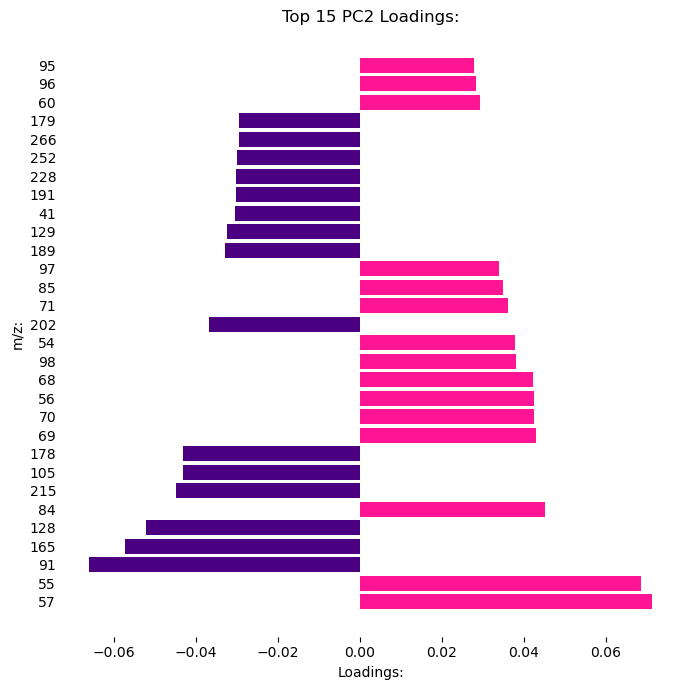

In [12]:
# Plot top 15 PC2 loadings:
pc2_loadings = loadings_df["PC2"].sort_values()
plot_loadings(pc2_loadings, "PC2")

It appears that positive PC2 loadings are dominated by aliphatic hydrocarbons such as $m/z$ $55$ ($C_4H_7+$), $57$ ($C_4H_9+$), $69$ ($C_5H_9+$), $70$ ($C_5H_10+$), and $71$ ($C_5H_11+$), consistent with lipid-derived compounds that could be associated with organic matter. Hence, these $m/z$ features could contribute to the separation of microbial samples along with kerogens and biochar.

On the other hand, the strongest negative PC2 loadings correspond to fragment ions characteristic of Polycyclic Aromatic Hydrocarbons (PAHs) like $m/z$ $128$ (napthalene), $m/z$ $165$ (phenalenyl), $m/z$ $178$ (phenanthrene/anthracene), and $m/z$ $202$ (pyrene) (Samarth 2025). PAHs are ubiquitous across terrestrial and extraterrestrial environments, and are commonly generated during the incomplete combustion of organic materials such as coal, oil and wood (Abdel-Shafy 2015). High loadings could therefore explain why coal, plastic, meteorites, and specific biochar as well as kerogen samples are pushed along the negative PC2 axis.

### Training & Evaluating Classifiers:

The supervised ML classification pipeline developed in previous notebooks and now incorporated in [`mlbiosig`](../../mlbiosig/) will now be employed to determine how well $m/z$ features can be used to discriminate between biotic and abiotic samples. In line with previous notebooks, Logistic Regression (LR), Support Vector Classifier (SVC), Random Forest Classifier (RF), and XGBoost will be trained and evaluated.

In [13]:
# Train and evaluate all four classifiers:
results, models, grid_searches = train_evaluate_classifiers(
    X_train, X_test, y_train, y_test
)


Coarse Hyperparameter Search: RandomizedSearchCV


Random Search:   0%|          | 0/4 [00:00<?, ?model/s]


[1/4] Logistic Regression
    Best CV F1: 0.973
    Parameters: {'solver': 'lbfgs', 'C': 100}

[2/4] SVC
    Best CV F1: 0.974
    Parameters: {'kernel': 'linear', 'gamma': 'auto', 'C': 10}

[3/4] Random Forest
    Best CV F1: 0.936
    Parameters: {'max_depth': 15, 'min_samples_split': 9, 'n_estimators': 385}

[4/4] XGBoost
    Best CV F1: 0.938
    Parameters: {'learning_rate': 0.5, 'max_depth': 20, 'n_estimators': 100}

Fine Hyperparameter Search: GridSearchCV


Grid Search:   0%|          | 0/4 [00:00<?, ?model/s]


[1/4] Logistic Regression
    Best CV F1: 0.973
    Parameters: {'C': 100, 'solver': 'lbfgs'}

[2/4] SVC
    Best CV F1: 0.978
    Parameters: {'C': 20, 'gamma': 'auto', 'kernel': 'linear'}

[3/4] Random Forest
    Best CV F1: 0.942
    Parameters: {'max_depth': 10, 'min_samples_split': 7, 'n_estimators': 485}

[4/4] XGBoost
    Best CV F1: 0.947
    Parameters: {'learning_rate': 0.4, 'max_depth': 10, 'n_estimators': 50}

Test-set Evaluation:


Evaluating Models:   0%|          | 0/4 [00:00<?, ?model/s]



Logistic Regression Results:
    CV F1 Score: 0.973
    F1 Score: 0.931
    ROC-AUC Score: 0.702


SVC Results:
    CV F1 Score: 0.978
    F1 Score: 0.966
    ROC-AUC Score: 0.702


Random Forest Results:
    CV F1 Score: 0.942
    F1 Score: 0.947
    ROC-AUC Score: 0.976


XGBoost Results:
    CV F1 Score: 0.947
    F1 Score: 0.982
    ROC-AUC Score: 0.988


### Visualising Classifier Performance:

**Confusion Matrices**

Confusion matrices are critical to visually assessing a binary classifier's performance by seeing which samples were correctly classified from false positive (FP) and false negatives (FN). FPs are incredibly important within the context of biosignature detection, as incorrectly identifying an abiotic sample as biotic could represent the potential of that classifier to make false biosignature detections. 

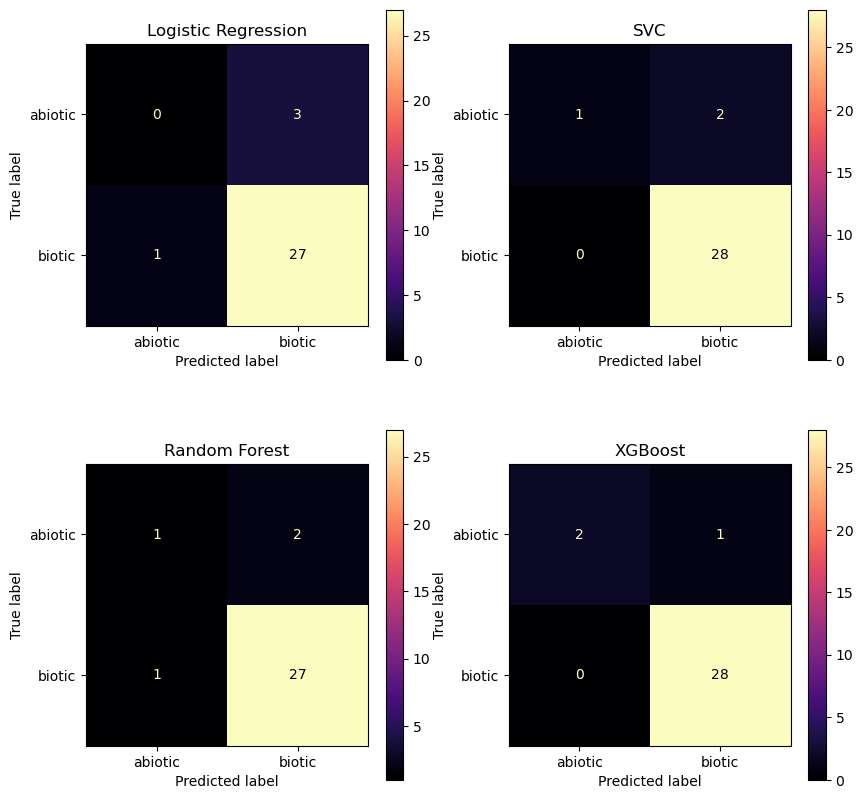

In [54]:
# Confusion matrices:
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()  # 2x2 axes plot
classes = le.classes_  # from fitted label encoder
# Plotting confusion matrix:
for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes).plot(
        ax=ax, cmap="magma"
    )
    ax.set_title(name)
plt.show()



**ROC Curves**

ROC curves evaluate classifier performance by plotting the True Positive Rate (TPR, also known as sensitivity) against the False Positive Rate (FPR, also known as specificity which corresponds to the proportion of TN predictions) across all possible decision thresholds for all four models (Nahm 2022). This therefore results in a trade-off between sensitivity and specificity in light of a threshold-independent assessment of a classifier's ability to discriminate between biotic and abiotic samples, with the $45^{\circ}$ diagonal line representing random classification.

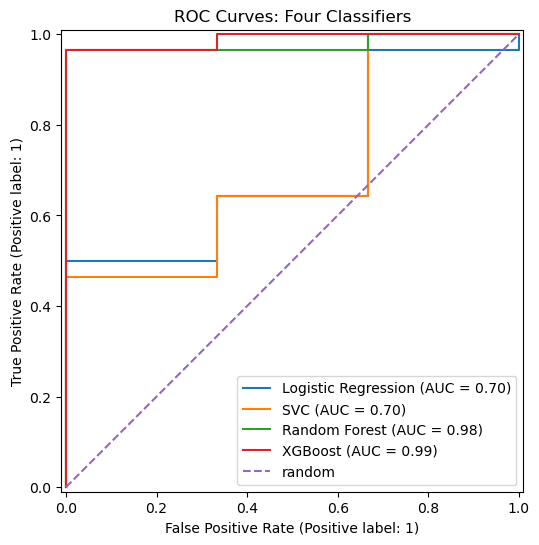

In [15]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 6))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "--", label="random")
ax.set_title("ROC Curves: Four Classifiers")
ax.legend(loc="best")
plt.show()

As discussed by (Nahm 2022), the above ROC curves exhibit a nonparametric empirical curve, indicated by its staircase appearance, as sensitivity and specificity are evaluated only at observed decision thresholds. On the one hand, this is advantageous because the curves are constructured directly from the data without assuming an underlying probability distribution. Furthermore, the classification threshold (also known as the optimal cut-off) is kept at the default value of $0.5$. As minimising FP biosignature detections in astrobiology research is a major focus of this work, optimising this threshold could be an exciting direction for future work.

Clearly, a major limitation of this ROC analysis is that the small dataset ($154$ samples) results in coarse curves, as each threshold correponds to a single observation. Nevertheless, as discussed by (Nahm 2022), increasing the sample size alone might not necessarily produce smoother ROC curves unless underlying distribution assumptions were introduced. ROC performance can also be summarised as Area Under the Curve (AUC), where AUC $> 0.5$ indicates that performance is more meaningful than random classification while AUC $> 0.8$ is considered acceptable (Nahm 2022). Clearly, RF at AUC $= 0.98$ achieves not only the most acceptable but an excellent score, while its tree-based counterpart XGBoost leads with the highest score at AUC $= 0.99$.

### Assessing Interpretability:

**Investigating Permutation Importance**

Permutation importance helps determine which specific $m/z$ values each model relies on to correctly predict sample classes i.e., biotic or abiotic. It also provides insight into potential chemical biomarkers contributing to model predictions. Given the high class imbalance in this dataset, F1 score is used as the evaluation metric. Furthermore, permutation importance will be calculated on the test set to assess feature importance on unseen data rather than how much a model memorised training data or noise.

Permutation importance in this work will be visualised using box plots in order to show the distribution of F1 score drops (or increase) across repeated permutations (determined by the `n_repeats` hyperparameter). The boxes represent the interquartile range (IQR), while the whiskers indicate more extreme values bounded by the range. This strategy will specifically be applied to LR and SVC, as tree-based classifiers will suffer from strong multicollinearity and distribute predictions across many features. This results in tree-based models making groups of individual features appear 'unimportant'.

In [16]:
# Function for computing & plotting permutation importance across each model:


def plot_permutation_importance(model, X_test, y_test, model_name, n_top=20, ax=None):
    """
    Computes and plots permutation importance for a given model,
    showing the `n_top` most important m/z features by mean
    F1 score drop when each feature is randomly shuffled.

    Parameters
    ----------
    model : fitted scikit-learn estimator
        Best model estimator from GridSearchCV.
    X_test : pandas.DataFrame
        Test feature matrix.
    y_test : numpy.ndarray
        Test labels.
    model_name : str
        Model name for plotting purposes.
    n_top : int
        Number of top features to display (default = 20).
    ax : matplotlib.axes.Axes
        Axes to plot permutation importances.
    """
    # Compute permutation importance on test set:
    perm_imp = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=30,
        random_state=42,  # for reproducibility
        scoring="f1",  # F1 score
        n_jobs=-1,  # use all CPUs
    )
    # Sort top n permutated feature importance:
    sorted_importances_idx = perm_imp.importances_mean.argsort()[-n_top:]
    importances = pd.DataFrame(
        perm_imp.importances[sorted_importances_idx].T,
        columns=X_test.columns[sorted_importances_idx],  # only testing set
    )
    # Plotting bar plot with whiskers for F1 score decrease:
    ax = importances.plot.box(
        vert=False,
        whis=10,
        patch_artist=True,
        boxprops=dict(facecolor="lightpink", color="deeppink"),
        whiskerprops=dict(color="deeppink"),
        capprops=dict(color="deeppink"),
        medianprops=dict(color="deeppink"),
        ax=ax,
    )
    ax.set_title(f"Feature Permutation Importances (Test Set): {model_name}")
    ax.axvline(x=0, color="k", linestyle="--")
    ax.set_xlabel("Decrease in F1 Score:")
    ax.set_ylabel("m/z:")
    ax.figure.tight_layout()

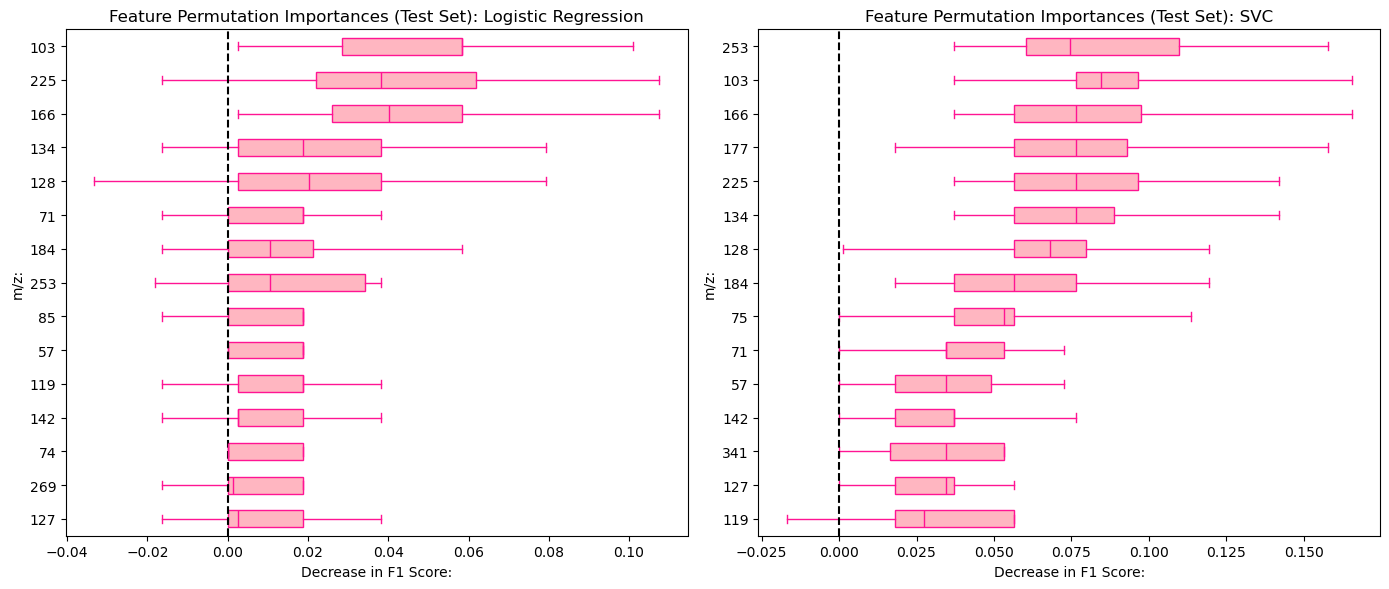

In [17]:
# Plot permutation importance for non-tree based classifers:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_permutation_importance(
    models["Logistic Regression"],
    X_test,
    y_test,
    "Logistic Regression",
    n_top=15,
    ax=axes[0],
)  # LR
plot_permutation_importance(
    models["SVC"], X_test, y_test, "SVC", n_top=15, ax=axes[1]
)  # SVC
fig.tight_layout()
plt.show()

For both LR and SVC, several features ($m/z$ $103, 128, 166, 225, 253$) consistently result in F1 score drops when permuted. SVC suffers larger decreases ($\sim 0.1$ as highest median) than LR ($\sim 0.05$ as highest median) which demonstrates how SVC more greatly relies on specific $m/z$ features. Furthermore, fragment ions appear across both models, such as $m/z$ $128$ (indicative of napthalene). It is interesting to note that permuting this feature occasionally improves LR's F1 score, suggesting it may introduce noise across test-set permutations.

The strategy for tree-based classifiers (RF and XGBoost) will be to use unsupervised hierarchical clustering on correlated features (scikit-learn Developers 2026). This strategy will involve clustering features that are correlated using Spearman rank-order correlations, where Ward's linkage will then be applied to the resulting correlation matrix composing of Spearman coefficients. The most important feature within each cluster will ultimately be selected as its representative.

In [18]:
# Creating Spearman correlation matrix to compute cluster distances:
corr = spearmanr(X_train).correlation
corr = (corr + corr.T) / 2  # make correlation matrix symmetric
np.fill_diagonal(corr, 1)  # 1 on diagonal for same feature correlation

# Perform hierarchical clustering using Ward's linkage
distance_matrix = 1 - np.abs(corr)  # convert corr --> distance matrix
dist_linkage = hierarchy.ward(squareform(distance_matrix))

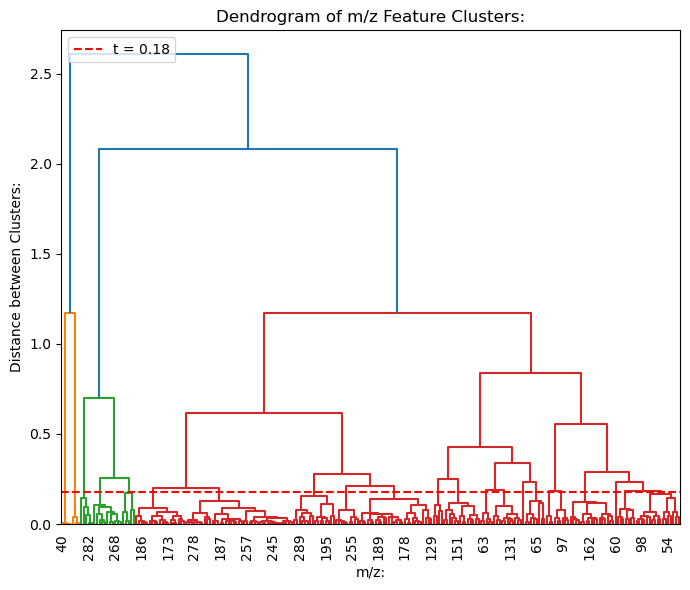

In [19]:
# Plot dendogram of hierarchical relationship between feature clusters:
fig, ax = plt.subplots(figsize=(7, 6))
dendro = hierarchy.dendrogram(
    dist_linkage, labels=X_train.columns.to_list(), ax=ax, leaf_rotation=90
)
dendro_idx = np.arange(0, len(dendro["ivl"]))
t = 0.18  # t hyperparameter
# Formatting:
ax.set_xlabel("m/z:")
ax.set_ylabel("Distance between Clusters:")
ax.set_title("Dendrogram of m/z Feature Clusters:")
leaf_positions = np.arange(5, len(dendro["ivl"]) * 10, 10)
ax.set_xticks(leaf_positions[::10])  # only show every 10th m/z feature
ax.set_xticklabels(dendro["ivl"][::10], fontsize=10)
ax.axhline(t, color="r", linestyle="--", label=f"t = {t}")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

Following manual tuning, the chosen clustering hyperparameter is `t=0.18`, as this value best balances reducing highly correlated features while retaining enough representative fragment ions, and thus $m/z$ values, to capture global chemical relationships.

In [20]:
# Creating hierarchical clusters based on sklearn documentation:
cluster_ids = hierarchy.fcluster(
    dist_linkage,  # Ward's linkage
    t,  # t hyperparameter manually tuned
    criterion="distance",
)
cluster_id_to_feature_ids = defaultdict(list)
for idx, cluster_id in enumerate(cluster_ids):
    cluster_id_to_feature_ids[cluster_id].append(idx)

# Choose representative feature with highest importance:
rf_importances = (
    grid_searches["Random Forest"]
    .best_estimator_.named_steps["classifier"]  # Pipeline structure
    .feature_importances_
)
xgb_importances = (
    grid_searches["XGBoost"]
    .best_estimator_.named_steps["classifier"]
    .feature_importances_
)

rf_rep_feat, xgb_rep_feat = [], []  # representative features per cluster

for feat in cluster_id_to_feature_ids.values():  # loop through each cluster
    # find feature with max. corresponding importance:
    rf_best_feat_per_cluster = max(feat, key=lambda i: rf_importances[i])  # RF
    rf_rep_feat.append(rf_best_feat_per_cluster)
    xgb_best_feat_per_cluster = max(feat, key=lambda i: xgb_importances[i])  # XGB
    xgb_rep_feat.append(xgb_best_feat_per_cluster)

# Resplitting train/test sets with representative features only:
rf_selected_features_names = X_train.columns[rf_rep_feat]  # RF
X_train_rf_cluster = X_train[rf_selected_features_names]
X_test_rf_cluster = X_test[rf_selected_features_names]

xgb_selected_features_names = X_train.columns[xgb_rep_feat]  # XGB
X_train_xgb_cluster = X_train[xgb_selected_features_names]
X_test_xgb_cluster = X_test[xgb_selected_features_names]

# Refitting RF & XGBoost models on reduced train/test sets using
# identical hyperparameters from previous fit:
rf_clustered = clone(grid_searches["Random Forest"].best_estimator_)  # RF
rf_clustered.fit(X_train_rf_cluster, y_train)
xgb_clustered = clone(grid_searches["XGBoost"].best_estimator_)  # XGB
xgb_clustered.fit(X_train_xgb_cluster, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(25.0, ...)"
,"copy copy: bool, default=TrueIf `False`, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True


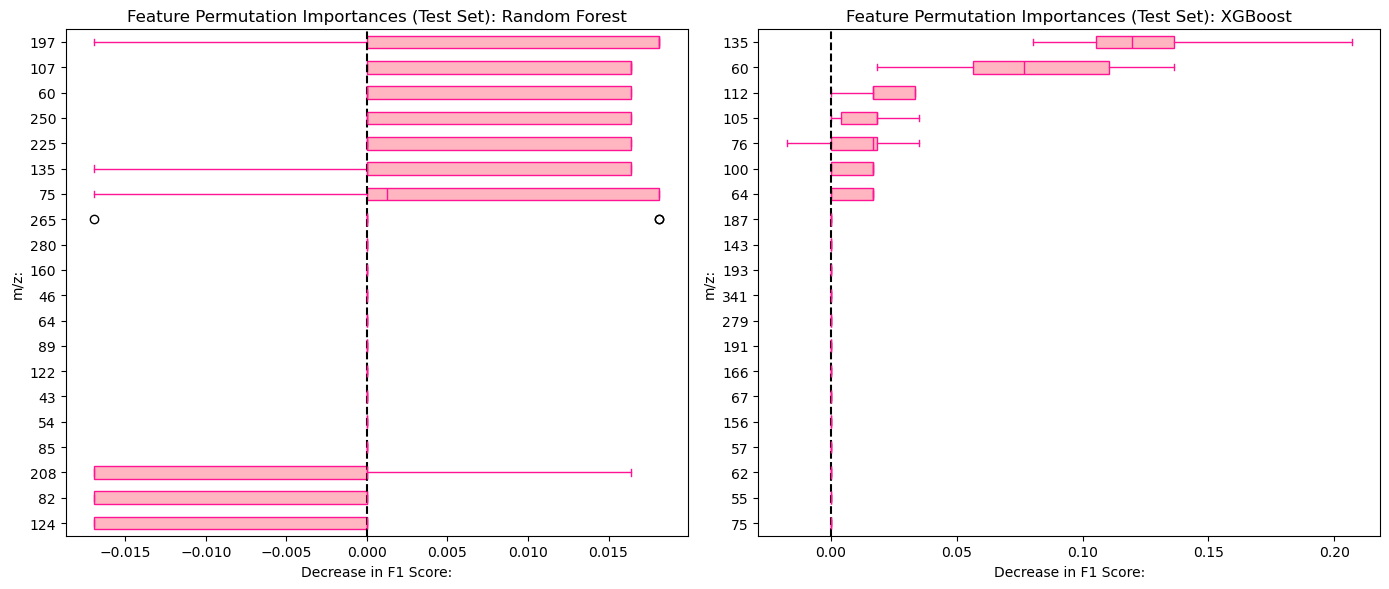

In [21]:
# Plot permutation importance for tree based classifers:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_permutation_importance(
    rf_clustered, X_test_rf_cluster, y_test, "Random Forest", ax=axes[0]
)  # RF
plot_permutation_importance(
    xgb_clustered, X_test_xgb_cluster, y_test, "XGBoost", ax=axes[1]
)  # XGBoost
fig.tight_layout()
plt.show()

RF shows small decreases in F1 score across varying $m/z$ permuted features ($\sim 10^{-2}$) compared to that of XGBoost ($\sim 10^{-1}$ and larger) by one order of magnitude, indicating its higher reliance on certain representative $m/z$ features. For example, in RF it appears that the largest decreases are associated with lighter fragment ions ($m/z$ $60$ and $75$) and heavier fragment ions ($m/z$ $107, 225$, and $225$). On the other hand, XGBoost is driven by $m/z$ $60$ and $135$, which produce a substantial median F1 score decrease between $\sim 0.08-0.12$. It is interesting to note that across both tree-based classifiers, performance is dominated by a combination of low $m/z$ fragment ions and heavier ions associated with geologically mature matter, while LR and SVC are primarily reliant on heavier fragment ions.

**Coefficent Analysis**

For LR and SVC classifiers, Linear SHAP and Kernel SHAP will not be applied as SHAP can become highly misleading for strongly correlated features (Aas 2021). In the case of Kernel SHAP, this is because conditional expectations in SHAP are approximated under the assumption of feature independence (Lundberg 2017), which is clearly violated by the strongly correlated $m/z$ chemical features included in this work.

In [22]:
# Fitted LR model:
lr_classifier = models["Logistic Regression"].named_steps["classifier"]

# Dataframe of coefficients from SVC model:
lr_coef_df = pd.DataFrame(
    {
        "m/z Feature": X_test.columns,  # testing set
        "Coefficient": lr_classifier.coef_[0],
    }
).sort_values(
    "Coefficient", key=abs, ascending=False
)  # coefs in abs order

# Top positive (biotic) and negative (abiotic) drivers:
print("Top 10 Biotic Drivers (+ve coefficients):")
print(lr_coef_df[lr_coef_df["Coefficient"] > 0].head(10))  # re-order
print("\nTop 10 Abiotic Drivers (-ve coefficients):")
print(lr_coef_df[lr_coef_df["Coefficient"] < 0].head(10))

Top 10 Biotic Drivers (+ve coefficients):
     m/z Feature  Coefficient
5             46     4.151894
4             45     3.761780
0             40     3.656481
21            64     3.435969
176          230     3.204915
34            79     3.145100
151          203     3.078984
11            54     2.942067
7             50     2.932773
162          215     2.723991

Top 10 Abiotic Drivers (-ve coefficients):
     m/z Feature  Coefficient
199          253    -3.789428
171          225    -3.380822
80           128    -3.353422
56           103    -3.265239
116          166    -2.924574
212          267    -2.579302
223          283    -2.497930
132          184    -2.422259
6             48    -2.268792
86           134    -2.097443


To explain the coefficient tables, the first column lists the dataframe index of the $m/z$ feature, followed by the corresponding $m/z$ feature, and finally the positive/negative coefficients which increase the likelihood of a biotic/abiotic prediction, respectively.

For LR, positive coefficients appear to be associated with lower $m/z$ fragment ions, suggesting that a higher intensity and therefore greater abundance of light hydrocarbon fragments fabour biotic classification. Examples of such fragments include $m/z$ $40, 45, 46, 50, 54, 64$, and $79$. In contrast, while there are some lighter ion fragments, abiotic predictions seem to be primarily driven by heavier $m/z$ fragment ions such as $m/z$ $103, 128, 225, 253$, and $283$ as the largest.

In [23]:
# Fitted SVC model:
svc_classifier = models["SVC"].named_steps["classifier"]

# Dataframe of coefficients from SVC model:
svc_coef_df = pd.DataFrame(
    {
        "m/z Feature": X_test.columns,  # testing set
        "Coefficient": svc_classifier.coef_[0],
    }
).sort_values(
    "Coefficient", key=abs, ascending=False
)  # coefs in abs order

# Top positive (biotic) and negative (abiotic) drivers:
print("Top 10 Biotic Drivers (+ve coefficients):")
print(svc_coef_df[svc_coef_df["Coefficient"] > 0].head(10))  # re-order
print("\nTop 10 Abiotic Drivers (-ve coefficients):")
print(svc_coef_df[svc_coef_df["Coefficient"] < 0].head(10))

Top 10 Biotic Drivers (+ve coefficients):
     m/z Feature  Coefficient
176          230     1.704012
5             46     1.476001
4             45     1.372596
21            64     1.169686
7             50     1.120245
151          203     1.087824
11            54     1.060086
33            78     1.020770
34            79     0.999617
162          215     0.982141

Top 10 Abiotic Drivers (-ve coefficients):
     m/z Feature  Coefficient
199          253    -1.815779
80           128    -1.183906
56           103    -1.131699
116          166    -1.073325
171          225    -0.890438
132          184    -0.835268
6             48    -0.751943
86           134    -0.731301
125          177    -0.677179
234          341    -0.665372


While SVC's abiotic predictions are again dominated by the same heavier fragment ions ($m/z$ $253, 128, 225, 166, 103$), one surprising exception is $m/z$ $230$ with the highest positive coefficient, suggesting tht high abundances of this ion favour biotic classification despite a high mass. Nevertheless, the majority of lighter $m/z$ fragment ions with positive coefficients generally agree with those identified by LR.

It is important to also recall that, while LR and SVC achieve higher CV F1 scores than both tree-based classifiers, both performed worse on the testing set and significantly lower in terms of ROC-AUC by $< 0.2$. 

**SHapley Additive exPlanations (SHAP): Global Analysis**

Due to strong multicollinearity between $m/z$ features, only Tree SHAP is used. Unlike Linear SHAP or Kernel SHAP, Tree SHAP allows feature dependencies to be handled when calculating Shapley values through the `feature_perturbation` hyperparameter. By setting `feature_perturbation="tree_path_dependent"`, conditional expectations are computed using the learned tree structure. 

To gain a global understanding of which fragment ions most strongly influence biotic and abiotic predictions for tree-based classifiers in this work, SHAP beeswarm summary plots will be invesigated for RF and XGBoost (Cooper 2026). The complete testing sets containing all $235$ $m/z$ features will be used here in order to explore all $m/z$ feature contributions.

RF SHAP values shape: (31, 235, 2)
Maximum SHAP value: 0.0686


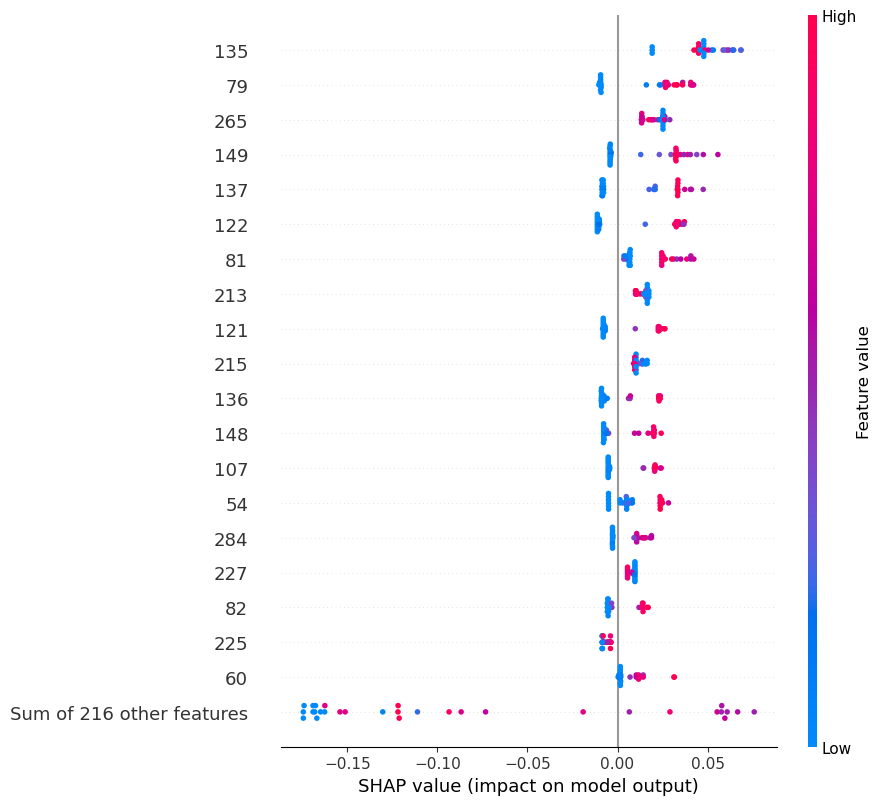

In [52]:
# Compute SHAP values for fitted RF:
fitted_rf_model = models["Random Forest"].named_steps[
    "classifier"
]  # fitted RF from Pipeline
rf_explainer = shap.TreeExplainer(
    fitted_rf_model, feature_perturbation="tree_path_dependent"  # model
)
rf_shap_values = rf_explainer(X_test)  # test set
print(f"RF SHAP values shape: {rf_shap_values.shape}")
print(f"Maximum SHAP value: {np.max(rf_shap_values.values):.4f}")

# Plotting SHAP beeswarm summary plots:
rf_shap_biotic = rf_shap_values[:, :, 1]  # biotic class = 1
shap.plots.beeswarm(rf_shap_biotic, max_display=20)

XGBoost SHAP values shape: (31, 235)
Maximum SHAP value: 1.4121


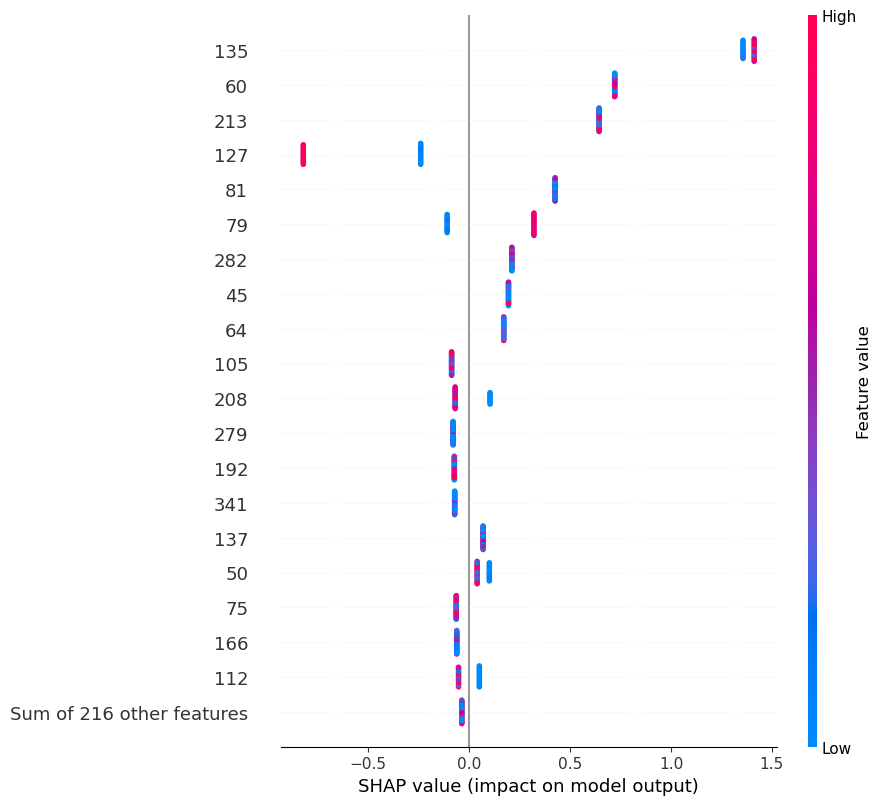

In [25]:
# Compute SHAP values for fitted XGBoost:
fitted_xgb_model = models["XGBoost"].named_steps[
    "classifier"
]  # fitted XGB from Pipeline
xgb_explainer = shap.TreeExplainer(
    fitted_xgb_model, feature_perturbation="tree_path_dependent"
)
xgb_shap_values = xgb_explainer(X_test)
print(f"XGBoost SHAP values shape: {xgb_shap_values.shape}")
print(f"Maximum SHAP value: {np.max(xgb_shap_values.values):.4f}")

# Plotting SHAP beeswarm summary plots:
# no need to slice as SHAP values are 2-D for XGB
shap.plots.beeswarm(xgb_shap_values, max_display=20)

**SHapley Additive exPlanations (SHAP): Local Analysis**

SHAP dependence plots are used to investigate how variation in the abundance of $m/z$ fragment ions influence tree-based model predictions. The fragment ions used for this investigation are chosen collectively based on the previous analysis in this work. Specifically, $m/z$ fragment ions and thus features are selected from those with large PCA loadings on PC1 ($\sim 0.15 < \text{loading} < 0.25$) and PC2 ($\sim |0.05| < \text{loading} < |0.1|$), high permutation importances for RF (IQR greater than $\sim 0.02$) and XGBoost (IQR greater than $\sim 0.05$), and the highest SHAP values in the global beeswarm analyses for RF and XGBoost.

<div align="center">

| m/z Feature | Interpretability Method |
|-------------|---------------|
| 60          | Permutation Importance, XGBoost SHAP |
| 79          | RF SHAP |
| 81          | RF SHAP, XGBoost SHAP |
| 107         | PCA, RF SHAP |
| 135         | Permutation Importance, RF SHAP, XGBoost SHAP |
| 137         | RF SHAP |
| 149         | RF SHAP |
| 265         | Permutation Importance, RF SHAP |

</div>

These selected fragment ions comprise of both lower $m/z$ hydrocarbon fragments as well as heavier $m/z$ fragment ions associated with geochemically mature matter. The dependence plots will therefore help further explore whether there is a repeated and recurring trend observed throughout this notebook: do lower $m/z$ fragment ions generally drive biotic predictions while heavier $m/z$ fragment ions favour abiotic predictions?


In [ ]:
shap_features = [
    60,  # fatty acids
    79,
    81,  # 2-furaldehyde, cellulose
    107,  # coals, methylphenols, biochar
    135,  # g-lignin
    137,  # guiaiacol, biochar
    149,  # plastics
    265,
]

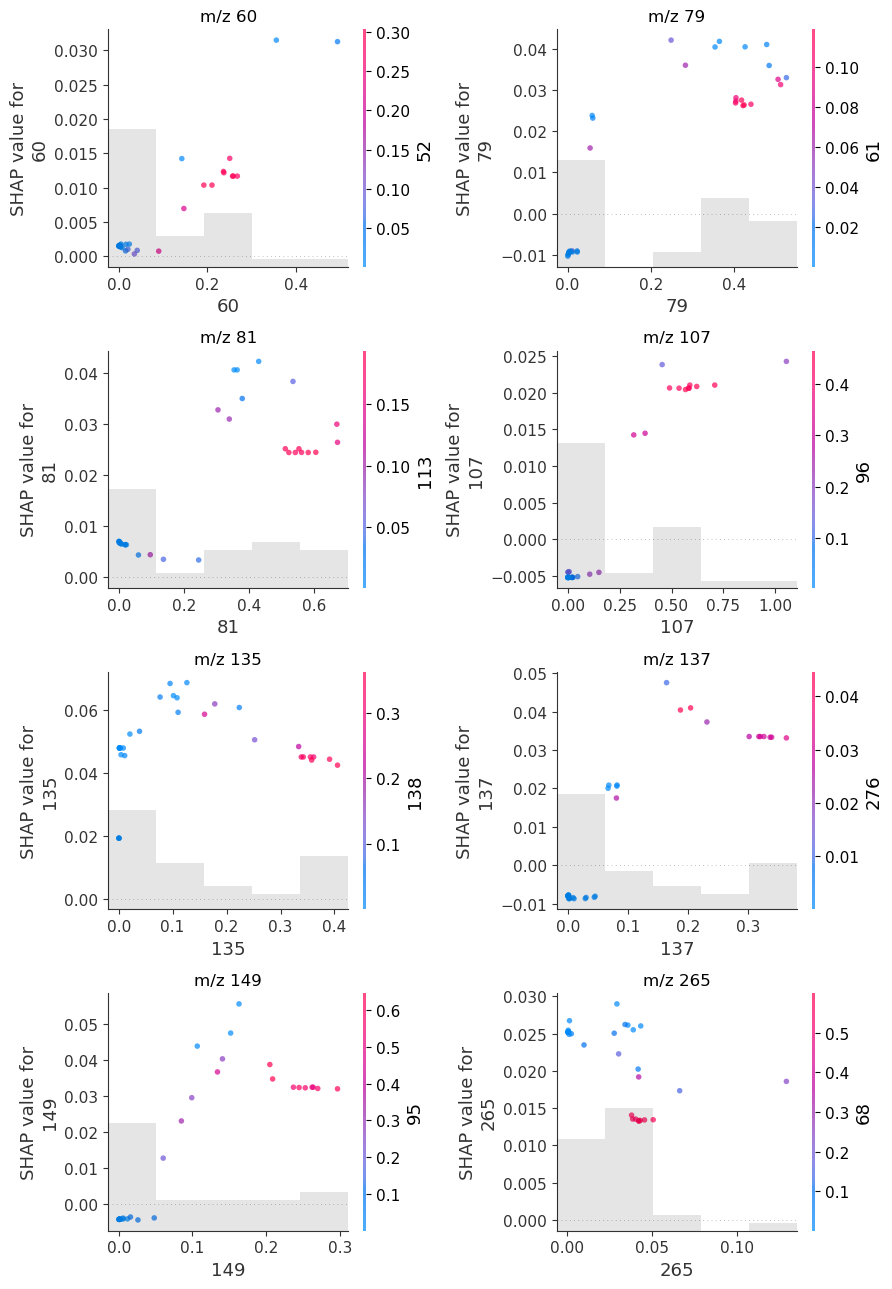

In [50]:
fig, axes = plt.subplots(4, 2, figsize=(9, 13))
axes = axes.ravel()  # flatten into a 1D array
rf_shap_summary = shap.Explanation(
    values=rf_shap_values.values[:, :, 1],  # biotic shap values
    base_values=rf_shap_values.base_values[:, 1],
    data=X_test.values,
    feature_names=[str(x) for x in X_test.columns],  # convert m/z to str
)

for ax, feature in zip(axes, shap_features):
    shap.plots.scatter(
        rf_shap_summary[:, str(feature)],
        color=rf_shap_summary,
        ax=ax,
        show=False,
        alpha=0.7,
    )

    ax.set_title(f"m/z {feature}")
plt.tight_layout()

Intensities can be interpreted as the abundance of a fragment ion in a given sample, whereby higher intensities translates into a greater abundance of that ion. Furthermore, all SHAP values should also be interpreted relative to the maximum observed value at $\sim 0.07$. The above SHAP dependence plots are automatically coloured by interacting features.

1. Light fragment ions with threshold-like behaviour: ($m/z$ $60, 79$)

At low abundances, these fragment ions produce SHAP values $\sim 0$ or slightly negative, which contributes minimally to classification. As abundance increases, the SHAP values become more positive, rising and reaching approximately $+0.03$ for $m/z$ $60$ and $+0.04$ for $m/z$ $79$, and thus favour biotic classification. The interacting features to these fragments, $m/z$ $52$, and $61$ respectively, also increase in abundance as $m/z$ $60$ and $79$ increase to the mid-ranges. It is interesting to note that the largest SHAP values for $m/z$ $60$ and $79$ occur when their interacting features are at their lowest abundance, suggesting that contributions to predictions depend on the relative abundance of correlated fragment ions rather than their abundance alone.

2. Intermediate fragment ions: ($m/z$ $81, 107, 137$)

Similar to the lighter fragment ions, lower abundances in these ions correspond to SHAP values $\sim 0$ or slightly negative, while increasing abundances result in larger positive SHAP values. This is strongly observed for $137$, with a SHAP value that reached $+0.05$. Feature interactions are also present, with $m/z$ $107$ and $137$ coloured by $96$ and $276$ respectively. In both ions, higher abundances of the interacting fragment align with increasing positive SHAP values. In contrast, $m/z$ $81$ resembles the lighter fragment ions such that high SHAP values occur when its heavier fragment ion ($m/z$ $113$) is low in abundance. 

3. Intermediate-Heavy fragment ions with smooth curves: ($m/z$ $135, 137, 149$)

These heavier fragment ions demonstrate a continuous but non-linear relationship with model classification predictions. Low abundances correspond to small SHAP values, while mid-range abundances produce a sharp rise in SHAP value. For $m/z$ $135$, this is observed the most as the SHAP value approaches the maximum observed magnitude at $\sim 0.07$, meaning this ion is the strongest contributor to biotic predictions. However, at the highest abundances, SHAP values across all ions decrease and eventually plateau, suggesting that their contribution decreases at extreme concentrations.

4. Heavy fragment ions: ($m/z$ $265$)

In contrast to the other ion fragments, $m/z$ $265$ produces its largest positive SHAP value at low abundances close to zero. However, the SHAP value gradually drops while remaining positive as the ions abundance increases. This suggests that lower concentrations of this fragment ion contribute more strongly to biotic classification than at higher abundances. 

### Conclusions:

As the final stage of the `mlbiosig` development process, the interpretability analyses performed in this notebook successfully bridges several methods together to provide a consistent chemical explanation for the ML predictions across all four classifiers. PCA illustrated how samples separate and cluster according to their underlying geochemistry even prior to supervised classification, while permutation importance, coefficient analysis, and SHAP collectively identified a small group of $m/z$ fragment ions that drive model predictions. Achieving the best overall performance, the two tree-based classifiers in this work relied on low $m/z$ features associated with light hydrocarbon fragments to push biotic predictions while heavier fragment ions favoured abiotic classification. SHAP dependence plots further revealed that these relationships are non-linear and, in some cases, strongly depend on feature interactions rather than the fragment ion's abundance alone. Consequently, these results reinforce how models are learning genuine chemical patterns and relationships that are interpretable and thus support the developement as well as usage of ML-driven biosignature interpretation from py-GC-MS data. Based on the developments of this notebook, the `mlbiosig` Python package is completed with the resulting [`evaluate.py`](../../mlbiosig/evaluate.py) module, providing tools for visual evaluation and interpretability analysis following ML classifier training. 

### Bibliography:

Matplotlib Development Team. (2026). *Plot a confidence ellipse of a two-dimensional dataset*. https://matplotlib.org/stable/gallery/statistics/confidence_ellipse.html

Radke, M., Schaefer, R.G., Leythaeuser, D., et al. (1980). *Composition of soluble organic matter in coals: relation to rank and liptinite fluorescence*. Geochimica et Cosmochimica Acta. (vol. 44, p. 1787-1800).
https://doi.org/10.1016/0016-7037(80)90228-8

Naraoka, H., Shimoyama, A. & Harada, K. (1999). *Molecular Distribution of Monocarboxylic Acids in Asuka Carbonaceous Chondrites from Antarctica*. Orig Life Evol Biosph 29, 187–201. https://doi.org/10.1023/A:1006547127028

Samarth, P., Fedoseev, G., Bulak. M., et al. (2025). *In situ characterization of volatile and refractory hydrocarbons produced by UV photolysis of interstellar C2H2 ice*. Astronomy & Astrophysics. (vol. 705). https://doi.org/10.1051/0004-6361/202556672

Abdel-Shafy, I. & Mansour, M.S.M. (2016). *A review on polycyclic aromatic hydrocarbons: Source, environmental impact, effect on human health and remediation*. Egyptian Journal of Petroleum. (vol. 25, p. 107-123). https://doi.org/10.1016/j.ejpe.2015.03.011.

Nahm, F.S. (2022). *Receiver operating characteristic curve: overview and practical use for clinicians*. Korean J Anesthesiol. https://doi.org/10.4097/kja.21209

scikit-learn Developers. (2026). *Permutation Importance with Multicollinear or Correlated Features*. https://scikit-learn.org/stable/auto_examples/inspection/plot_permutation_importance_multicollinear.html

Aas, K., Jullum, M., Løland, A. (2021). *Explaining individual predictions when features are dependent: More accurate approximations to Shapley values*. Artificial Intelligence. (vol. 298) https://doi.org/10.1016/j.artint.2021.103502

Lundberg, S. & Lee, S. I. (2017). *A Unified Approach to Interpreting Model Predictions*. https://arxiv.org/abs/1705.07874

Cooper, A. (2026). *SHAP Analysis Guide*. GitHub. https://github.com/AidanCooper/shap-analysis-guide